In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **2. Visualization**

In [32]:
cleaned_df = pd.read_csv("../cleaned_dataset.csv")
encoded_df = pd.read_csv('../encoded_dataset.csv')

### **Distribution of Age**

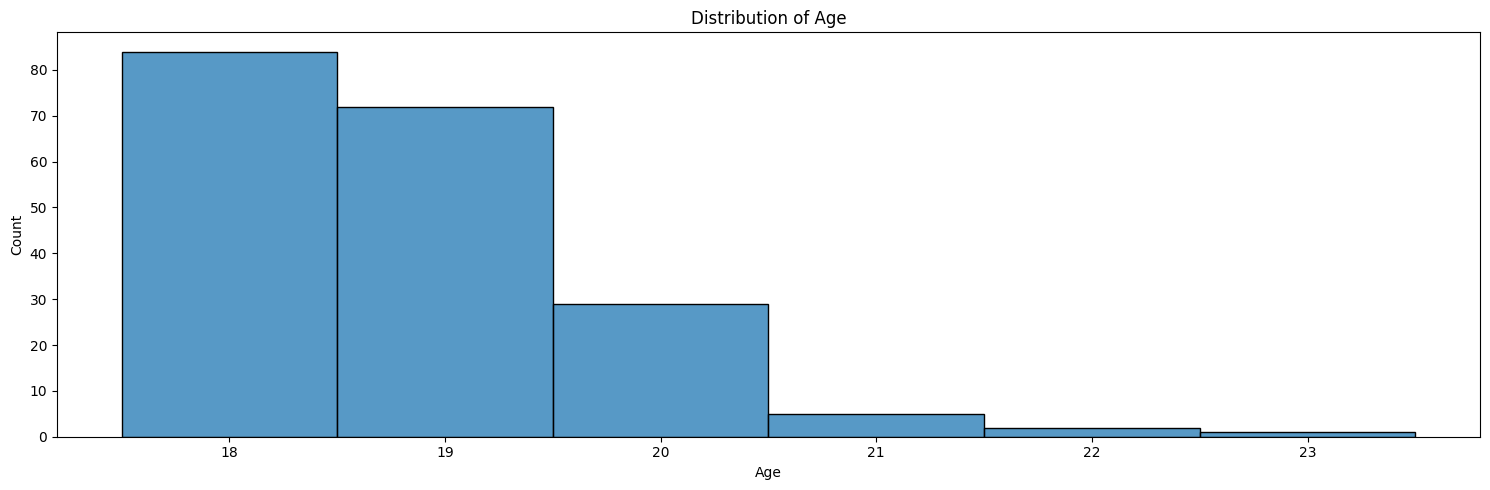

In [33]:
# Histogram of age
plt.figure(figsize=(15, 5))

sns.histplot(cleaned_df["age"], discrete=True)
plt.title("Distribution of Age")

plt.tight_layout()
plt.xlabel("Age")
plt.show()

### **Distribution of Gender**

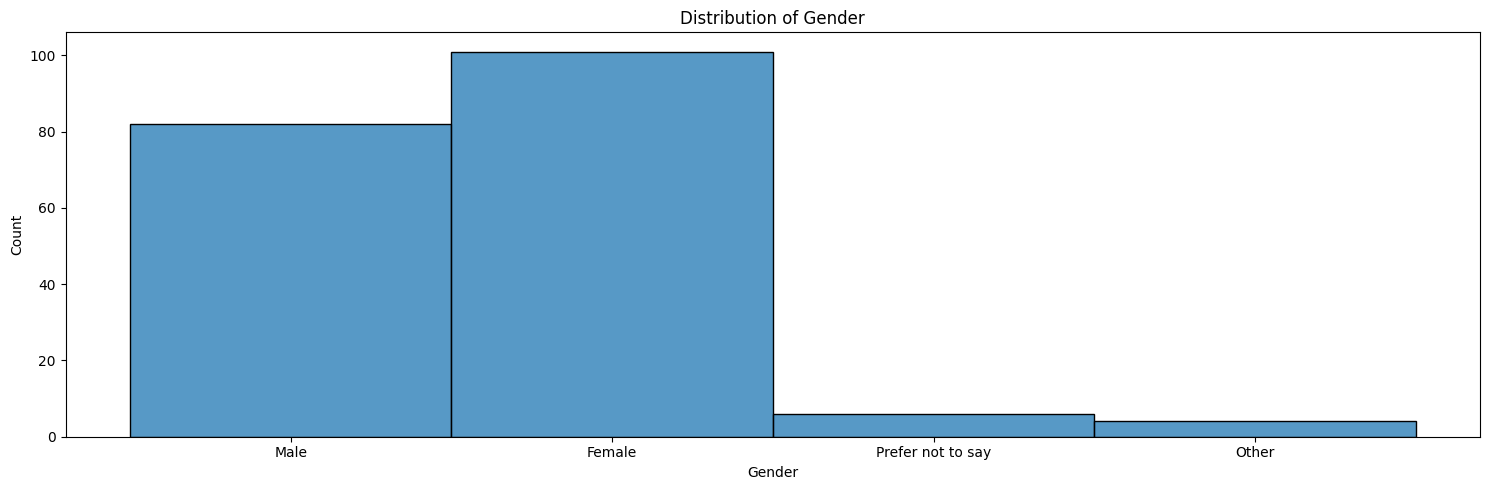

In [34]:
# Histogram of gender
plt.figure(figsize=(15, 5))

sns.histplot(cleaned_df["gender"])
plt.title("Distribution of Gender")

plt.tight_layout()
plt.xlabel("Gender")
plt.show()

### **Distribution of GPA**

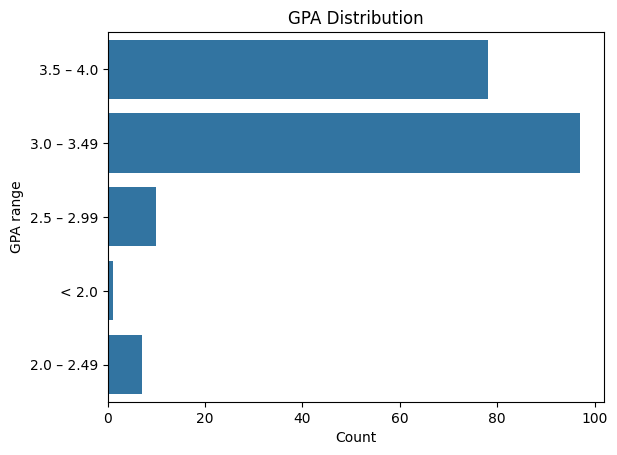

In [35]:
# Visulization of gpa
sns.countplot(data=cleaned_df["gpa_range"])
plt.title("GPA Distribution")
plt.xlabel("Count")
plt.ylabel("GPA range")
plt.show()

### **Study Hours vs GPA**

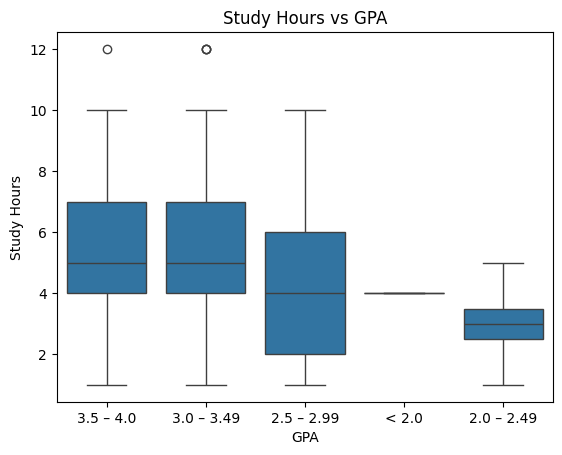

In [36]:
# Correlation between gpa and self-studying hours
sns.boxplot(x=cleaned_df["gpa_range"], y=cleaned_df["self_study_hours"], data=cleaned_df)
plt.title("Study Hours vs GPA")
plt.xlabel("GPA")
plt.ylabel("Study Hours")
plt.show()

In [37]:
# cleaned_df['study_environment'] = cleaned_df['study_environment'].str.strip()

# study_environment_map = {
#     "Private space (i.e. bedroom, home office)": "Private Space",
#     "Open learning space (i.e. university library)": "Open Space",
#     "Collaborative space (i.e. group study room)": "Collab Space",
#     "Cafes": "Café",
    
#     "Dormitory": "Private Space",
#     "Any quiet space": "Private Space",
#     "Flexible": "Flexible/Multiple",
#     "Flexible, could be private place or open learning space": "Flexible/Multiple",
#     "All above": "Flexible/Multiple",
#     "all places above, and all places possible like pantry rooms, JA102, etc": "Flexible/Multiple"
# }

# cleaned_df['study_environment'] = cleaned_df['study_environment'].map(study_environment_map)
# print(cleaned_df['study_environment'].value_counts())

In [38]:
# # Plot study location vs focus
# plt.figure(figsize=(12, 6))
# sns.countplot(data=cleaned_df, x='study_environment', hue='focus_frequency')
# plt.title('Focus frequency vs. Study environment')
# plt.show()

## **Distribution of features**

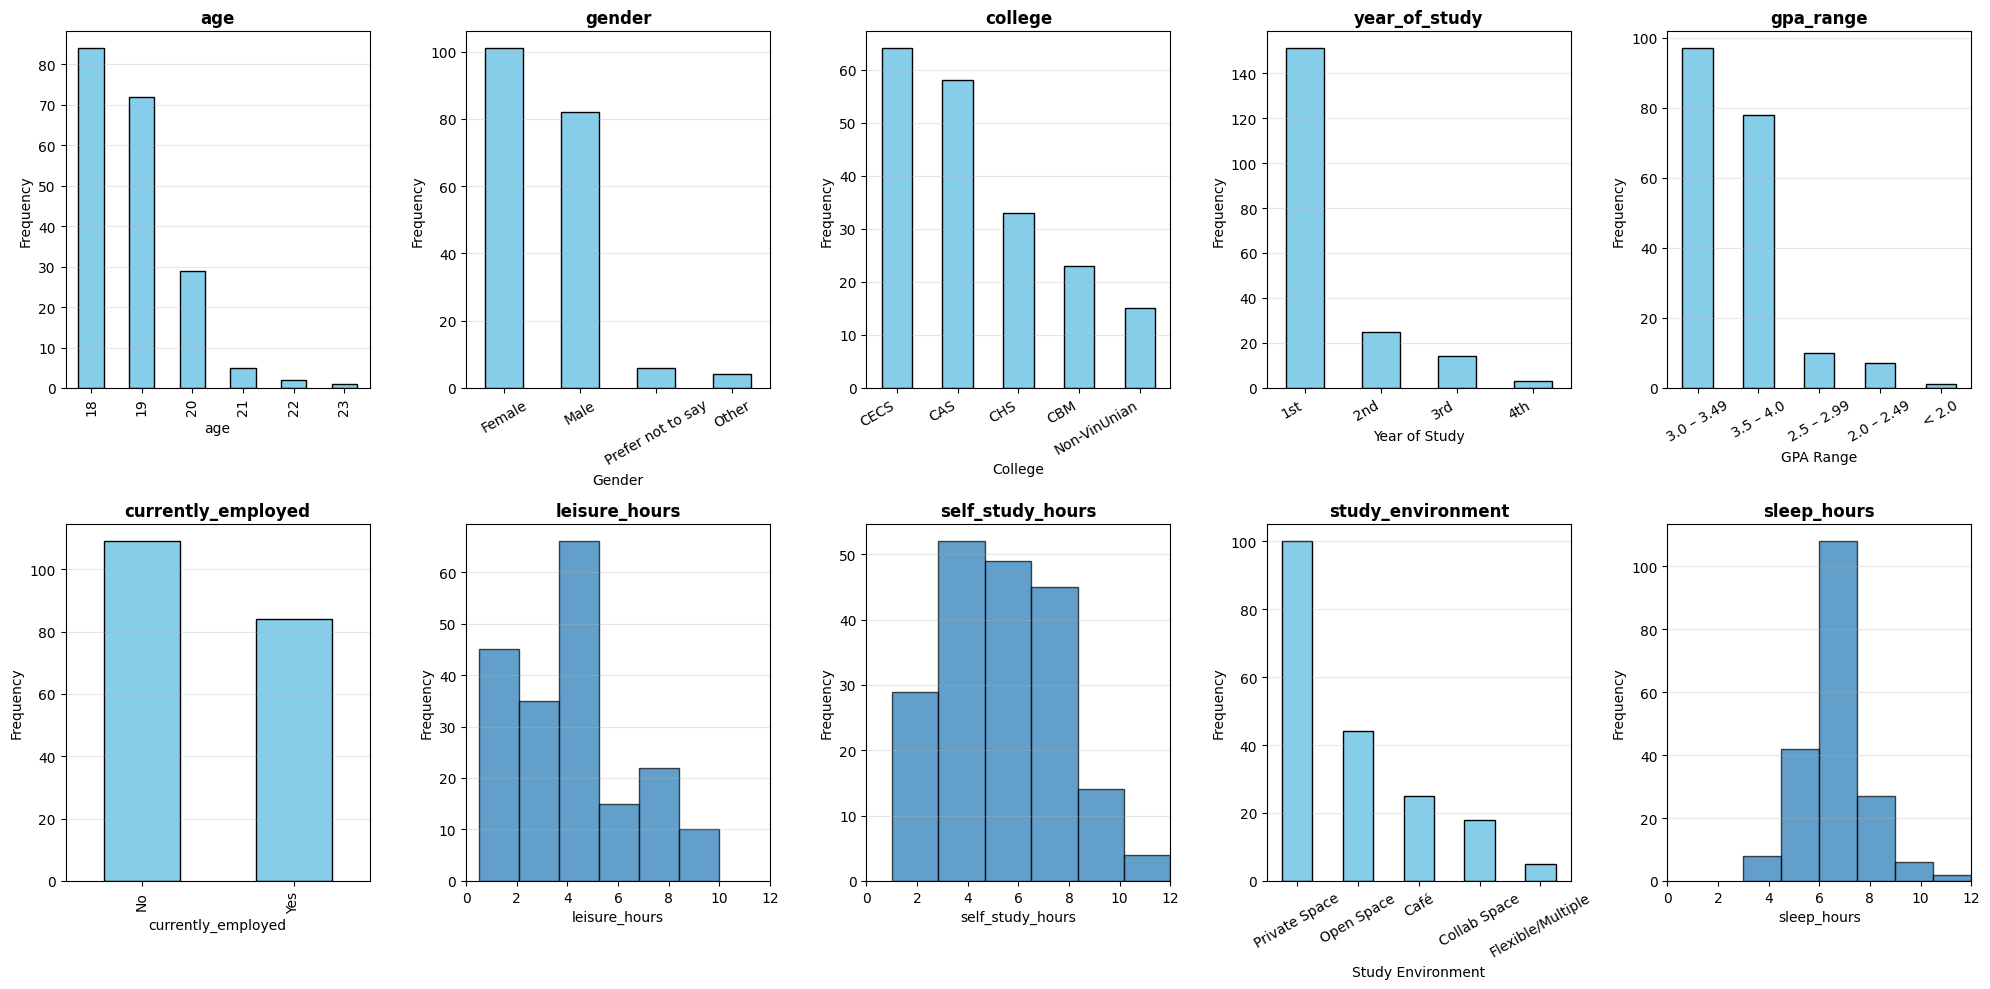

In [54]:
# Multi-column histogram subplots (first 10 columns excluding timestamp)
fig, axes = plt.subplots(2, 5, figsize=(20, 10))

# Flatten axes array for easier iteration
axes = axes.flatten()

# Get first 10 columns excluding timestamp
columns_to_plot = [col for col in cleaned_df.columns if col != 'timestamp'][:10]

# Create histogram for each column
for idx, col in enumerate(columns_to_plot):
    ax = axes[idx]

    # Check if column is numeric or categorical
    if cleaned_df[col].dtype in ['float64', 'int64'] and col != "age":
        ax.hist(cleaned_df[col], bins=6, edgecolor='black', alpha=0.7)
        ax.set_xlim(0, 12)
        ax.set_xticks(range(0,13,2))
    elif col == "age":
        cleaned_df[col].value_counts().plot(kind = "bar", ax = ax, color = "skyblue", edgecolor = "black")
    else:
        # For categorical data, create a value count plot
        cleaned_df[col].value_counts().plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')

    ax.set_title(f'{col}', fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)

    # Customize specific columns
    if col == 'college':
        college_labels = ['CECS', 'CAS', 'CHS', 'CBM', 'Non-VinUnian']
        ax.set_xticklabels(college_labels, rotation=30, ha='right')
        ax.set_xlabel('College')
    elif col == 'year_of_study':
        year_labels = ['1st', '2nd', '3rd', '4th', '5th', '6th']
        ax.set_xticklabels(year_labels[:len(ax.get_xticklabels())], rotation=30, ha='right')
        ax.set_xlabel('Year of Study')
    elif col == 'gpa_range':
        ax.tick_params(axis='x', rotation=30)
        ax.set_xlabel('GPA Range')
    elif col == 'study_environment':
        ax.tick_params(axis='x', rotation=30)
        ax.set_xlabel('Study Environment')
    elif col == "gender":
        ax.tick_params(axis ='x', rotation=30)
        ax.set_xlabel("Gender")
    else:
        ax.set_xlabel(col)

plt.tight_layout()
plt.show()

### **Correlation heatmap**

Text(0.5, 1.0, 'Heatmap correlation between all features')

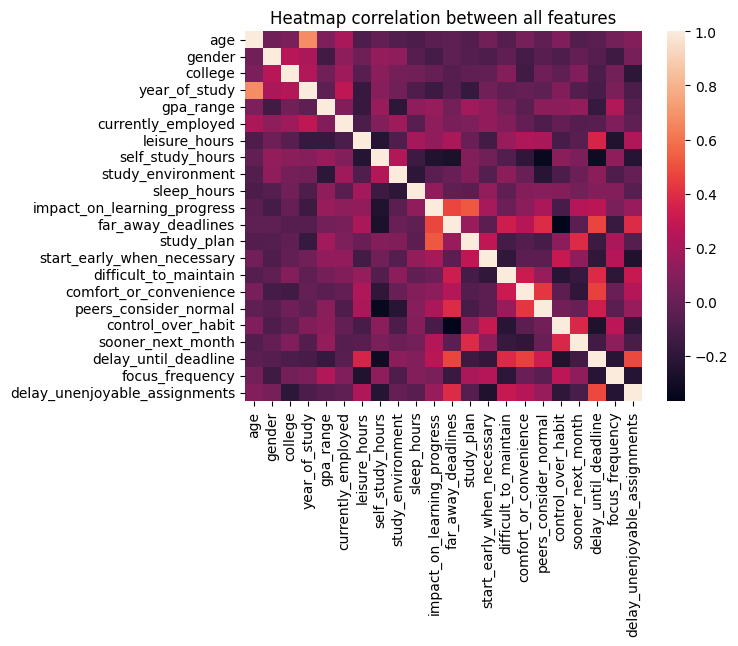

In [45]:
sns.heatmap(encoded_df.drop(columns = ["timestamp", "data_quality_check", "referrer"]).corr())
plt.title("Heatmap correlation between all features")

## **Linkert Visualization**

In [55]:
encoded_df.columns

Index(['timestamp', 'age', 'gender', 'college', 'year_of_study', 'gpa_range',
       'currently_employed', 'leisure_hours', 'self_study_hours',
       'study_environment', 'sleep_hours', 'impact_on_learning_progress',
       'far_away_deadlines', 'study_plan', 'start_early_when_necessary',
       'difficult_to_maintain', 'data_quality_check', 'comfort_or_convenience',
       'peers_consider_normal', 'control_over_habit', 'sooner_next_month',
       'delay_until_deadline', 'focus_frequency',
       'delay_unenjoyable_assignments', 'referrer'],
      dtype='str')

In [58]:
linkert_col = ["impact_on_learning_progress",
               "far_away_deadlines",
               "study_plan",
               "start_early_when_necessary",
               "difficult_to_maintain",
               "comfort_or_convenience",
               "peers_consider_normal",
               "control_over_habit",
               "sooner_next_month",
               "delay_until_deadline"]

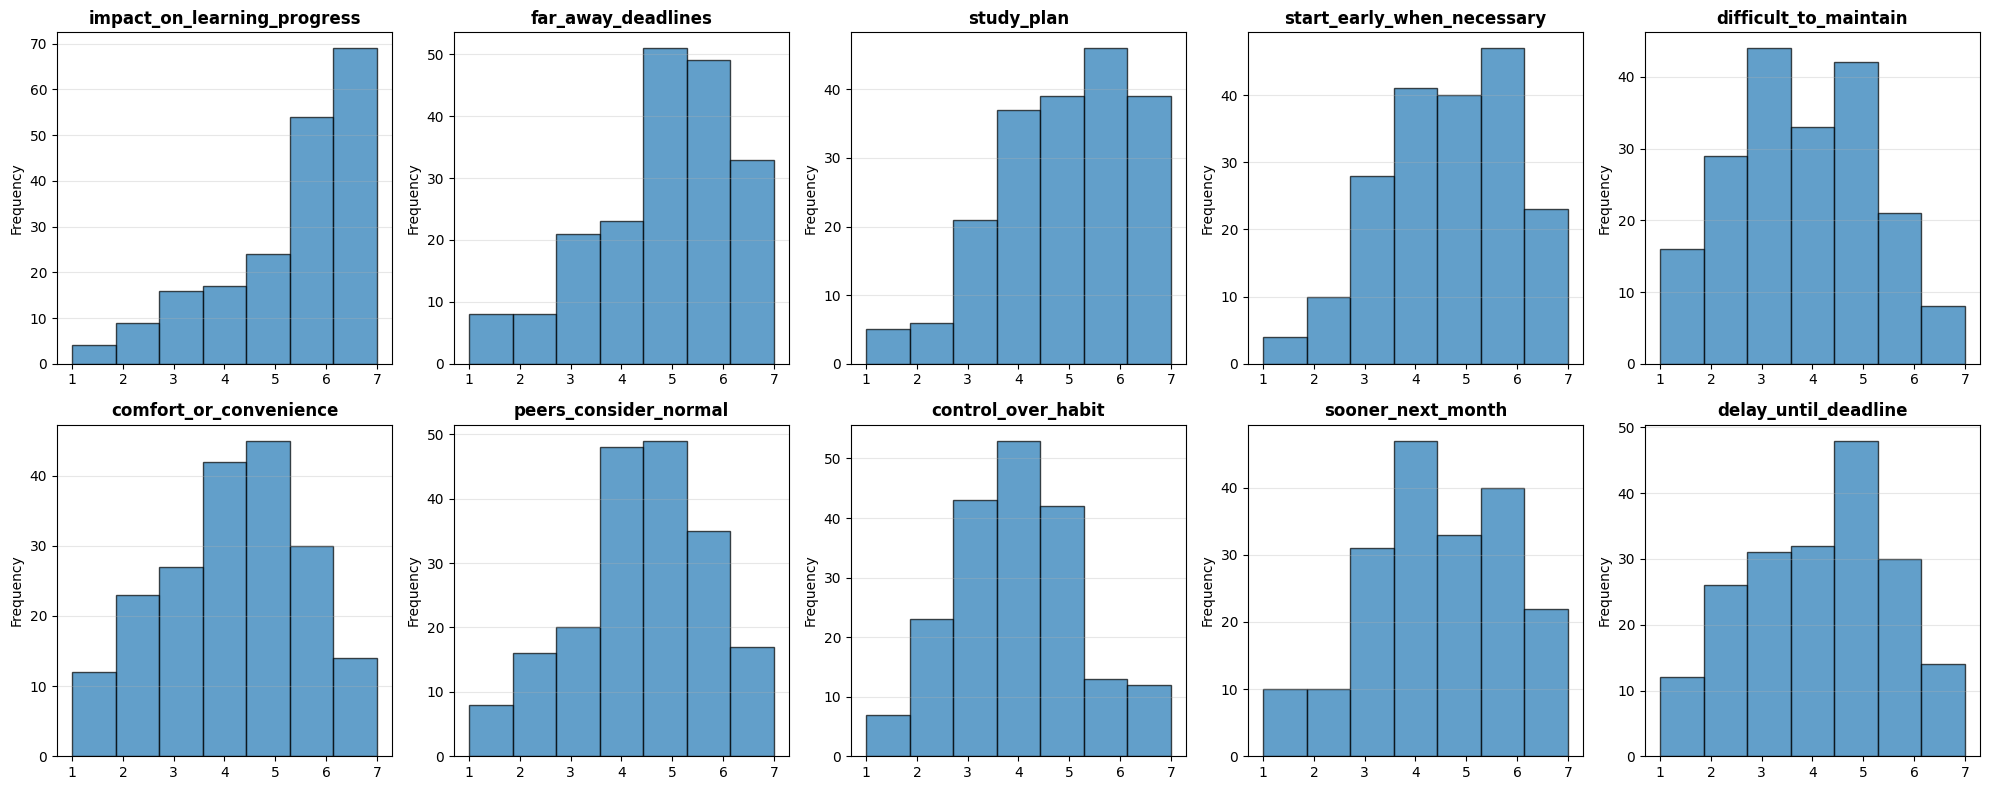

In [64]:
# Multi-column histogram subplots (first 10 columns excluding timestamp)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Flatten axes array for easier iteration
axes = axes.flatten()


# Create histogram for each column
for idx, col in enumerate(linkert_col):
    ax = axes[idx]

    ax.hist(encoded_df[col], bins=7, edgecolor='black', alpha=0.7)


    ax.set_title(f'{col}', fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()